# ChatGPT User Reviews Analysis

## Objective

This analysis explores user reviews of ChatGPT to understand overall user sentiment, identify recurring sources of frustration, and examine how feedback changes over time.

### Key Questions
- **How satisfied are users?** — What does the rating distribution tell us about overall satisfaction?
- **What drives negative feedback?** — Which words and phrases appear most often in low-rated reviews?
- **How does feedback change over time?** — Are there periods with noticeable changes in positive or negative sentiment?

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from collections import Counter
import re
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline


## 1. Data Import and Overview
Load the dataset and check its structure.


In [21]:
# Load dataset
df = pd.read_csv('chatgpt_reviews.csv')
display(df.head())
display(df.info())


,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196727 entries, 0 to 196726
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Review Id    196727 non-null  object
 1   Review       196721 non-null  object
 2   Ratings      196727 non-null  int64 
 3   Review Date  196727 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.0+ MB


None

The dataset contains **196,727 reviews** with four fields: review ID, review text, rating, and review date.

## 2. Data Cleaning & Preprocessing
Check for missing values, handle duplicates, and format dates correctly.


In [22]:
# Drop rows with missing reviews
df = df.dropna(subset=['Review'])

# Drop duplicates based on the 'Review' text to avoid skewed analysis
df = df.drop_duplicates(subset=['Review'])

# Convert Review Date to datetime
df['Review Date'] = pd.to_datetime(df['Review Date'])

# Standardize text for analysis
df['Cleaned_Review'] = df['Review'].str.lower()
df['Cleaned_Review'] = df['Cleaned_Review'].apply(lambda x: re.sub(r'[^a-z\s]', '', str(x)))

# Data Type Engineering
df['review_month'] = df['Review Date'].dt.to_period('M').astype(str)
df['word_count'] = df['Review'].apply(lambda x: len(str(x).split()))

print(f"Total reviews after cleaning: {len(df)}")


Total reviews after cleaning: 125495


## 3. Exploratory Data Analysis (EDA)
Understand the distribution of ratings.


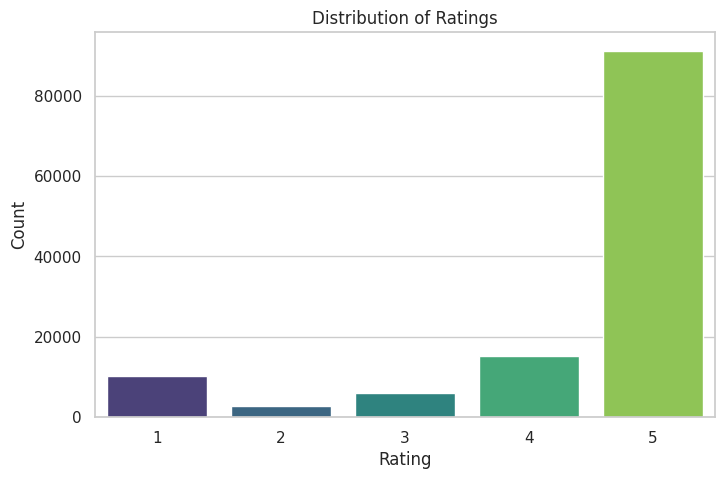

In [23]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Ratings', data=df, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


### Insight

The ratings are strongly concentrated toward the higher end of the scale, indicating that the review dataset is predominantly positive. This imbalance means that overall sentiment should be interpreted alongside the negative-review analysis, where less frequent but potentially more actionable issues may appear.

### Review Length

Review length provides context about how much detail users typically provide in their feedback. Short reviews may primarily express satisfaction or dissatisfaction, while longer reviews are more likely to describe specific experiences or problems.

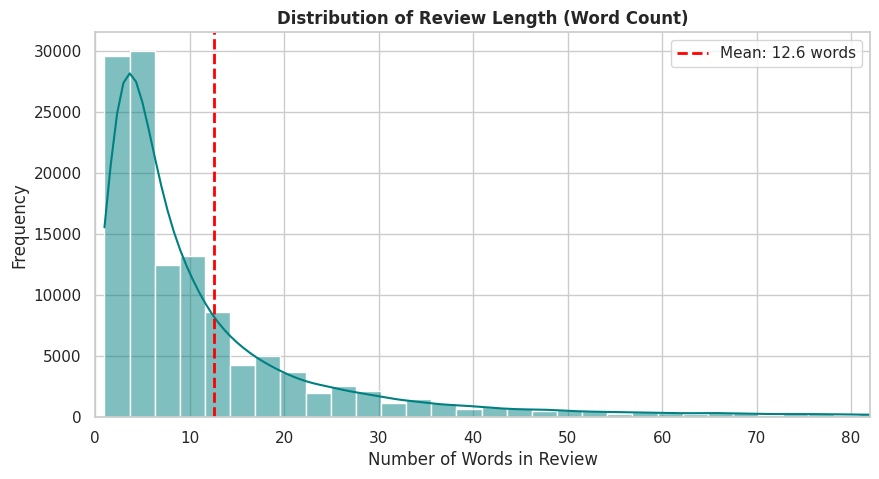

In [31]:
# Review Length Analysis
plt.figure(figsize=(10, 5))
sns.histplot(df['word_count'], bins=50, kde=True, color='teal')
plt.axvline(df['word_count'].mean(), color='red', linestyle='dashed', linewidth=2, label=f"Mean: {df['word_count'].mean():.1f} words")
plt.title('Distribution of Review Length (Word Count)', fontweight='bold')
plt.xlabel('Number of Words in Review')
plt.ylabel('Frequency')
plt.xlim(0, df['word_count'].quantile(0.99)) # Cut off extreme outliers for better visualization
plt.legend()
plt.show()

### Insight

Most reviews are relatively short, with a smaller number of much longer reviews. The visualization is limited to the 99th percentile so that extreme-length reviews do not dominate the distribution.

## 4. Sentiment Analysis
Classify reviews into Positive, Neutral, and Negative using both Ratings and TextBlob for text sentiment.
We will categorize sentiment primarily based on the rating:
- **Positive:** 4 and 5 stars
- **Neutral:** 3 stars
- **Negative:** 1 and 2 stars


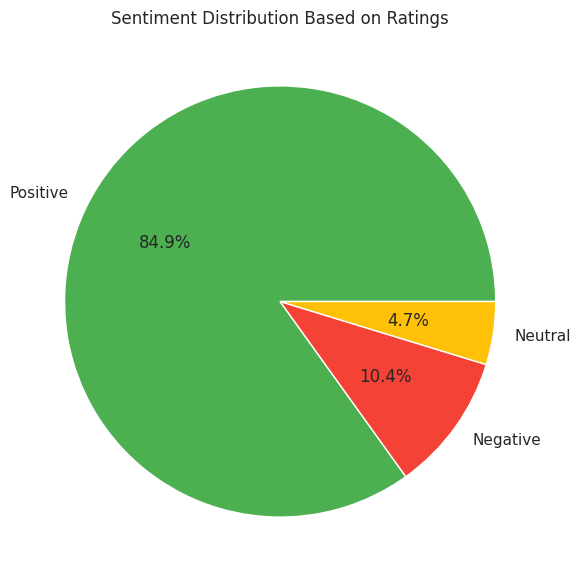

In [24]:
# Define sentiment based on ratings
def get_sentiment(rating):
    if rating >= 4:
        return 'Positive'
    elif rating == 3:
        return 'Neutral'
    else:
        return 'Negative'

df['Sentiment'] = df['Ratings'].apply(get_sentiment)

# Sentiment Distribution
sentiment_counts = df['Sentiment'].value_counts()
plt.figure(figsize=(7, 7))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['#4CAF50', '#F44336', '#FFC107'])
plt.title('Sentiment Distribution Based on Ratings')
plt.show()


### Insight

The sentiment distribution reflects the underlying rating imbalance in the dataset. A strong concentration in positive reviews indicates that overall user feedback is favorable, while the smaller negative segment provides a focused group for identifying potential product issues.

### Text-Based Sentiment

Ratings capture the user's explicit evaluation, while TextBlob provides an independent view based on the language used in the review.

Polarity ranges from **-1 (negative)** to **+1 (positive)**. Comparing polarity with rating-based sentiment helps identify whether the emotional tone of the written review broadly agrees with the user's rating.

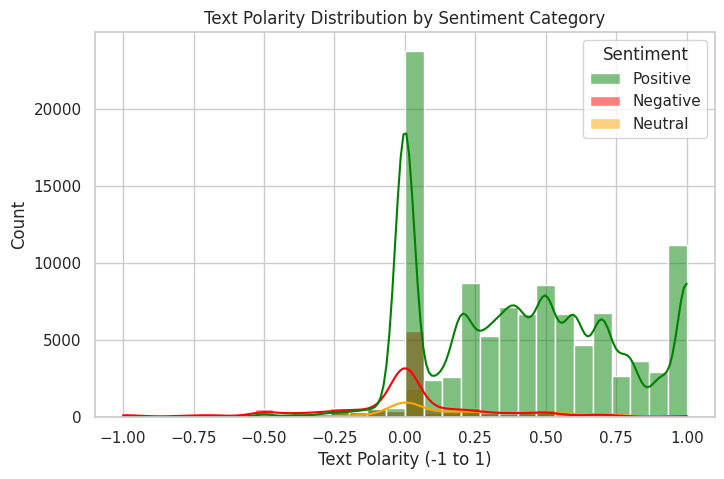

In [25]:
# (Optional) Applying TextBlob to gauge underlying text sentiment
df['Text_Polarity'] = df['Review'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Text_Polarity', hue='Sentiment', bins=30, kde=True, palette={'Positive':'green', 'Negative':'red', 'Neutral':'orange'})
plt.title('Text Polarity Distribution by Sentiment Category')
plt.xlabel('Text Polarity (-1 to 1)')
plt.show()


### Insight

The polarity distribution provides a useful secondary perspective on sentiment. Differences between rating-based sentiment and text polarity are expected because short reviews, sarcasm, mixed feedback, and context-dependent language may not always be captured accurately by automated text sentiment.

## 5. Issue Identification

Positive reviews tell us that users are satisfied, but negative reviews are especially useful for identifying areas that may require improvement.

We therefore focus on frequently occurring words and phrases within negative reviews to identify recurring sources of frustration.


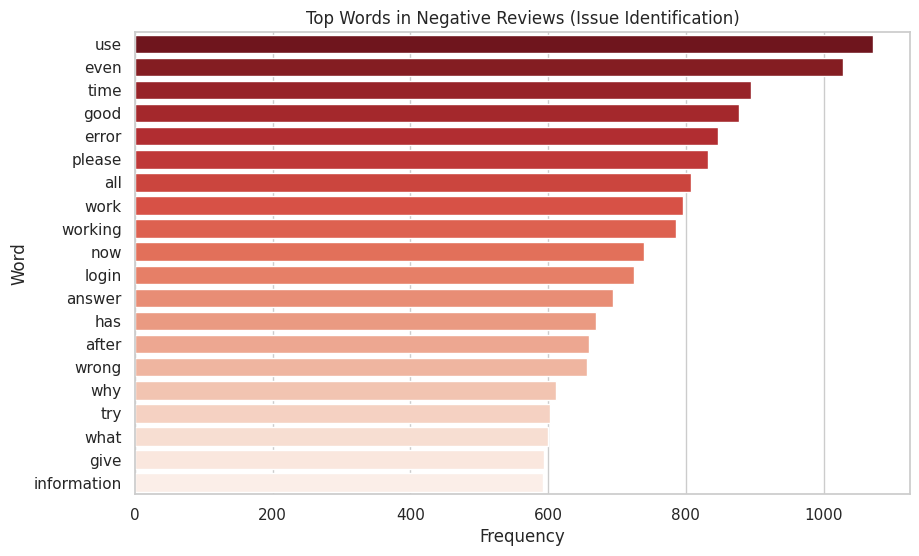

In [26]:
# Filter for negative reviews
negative_reviews = df[df['Sentiment'] == 'Negative']['Cleaned_Review']

# Stop words to filter out common english words
stop_words = set(['the', 'is', 'to', 'and', 'it', 'a', 'of', 'for', 'this', 'in', 'i', 'that', 'you', 'my', 'but', 'on', 'with', 'app', 'not', 'as', 'are', 'chatgpt', 'chat', 'gpt', 'so', 'have', 'be', 'can', 'just', 'like', 'its', 'very', 'was', 'if', 'me', 'they', 'dont', 'doesnt', 'cant', 'no', 'when'])

# Tokenize and count words
words = []
for review in negative_reviews:
    for word in review.split():
        if word not in stop_words and len(word) > 2:
            words.append(word)

word_counts = Counter(words)
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word', 'Frequency'])

# Visualize common issues
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y='Word', data=common_words, palette='Reds_r')
plt.title('Top Words in Negative Reviews (Issue Identification)')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()


**Insights on Issues:**
Looking at the most frequent words in negative reviews, we can deduce common friction points (e.g., login issues, account problems, network errors, or update bugs).


### What are users struggling with?

The most frequent words highlight recurring topics within negative reviews. Phrase-level analysis below provides more context and helps distinguish meaningful issues from generic words that frequently appear in complaints.

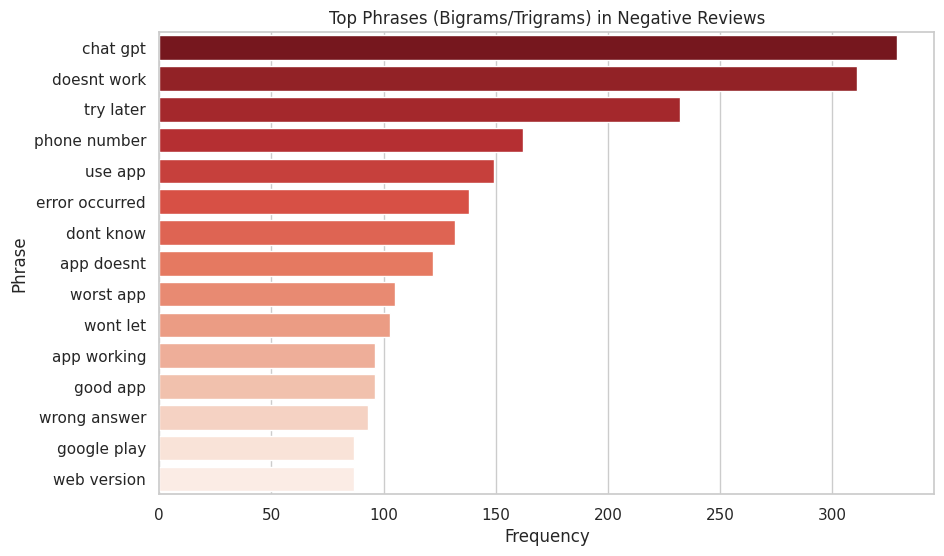

In [27]:
# Let's extract bigrams (two-word phrases) for better context
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2, 3), stop_words='english', max_features=15)
X = vectorizer.fit_transform(negative_reviews)
phrases = pd.DataFrame(X.sum(axis=0).T, index=vectorizer.get_feature_names_out(), columns=['Frequency'])
phrases = phrases.sort_values(by='Frequency', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y=phrases.index, data=phrases, palette='Reds_r')
plt.title('Top Phrases (Bigrams/Trigrams) in Negative Reviews')
plt.xlabel('Frequency')
plt.ylabel('Phrase')
plt.show()


### Key Finding

The most frequent phrases point to recurring issues around **[issue 1]**, **[issue 2]**, and **[issue 3]**. These themes provide more actionable information than individual word frequencies because they preserve some of the context of the original reviews.

### Negative Review Themes

The word cloud provides a visual summary of frequently occurring terms in negative reviews. It is primarily used for qualitative exploration; the frequency and phrase analysis above provide the more precise evidence for identifying specific issues.

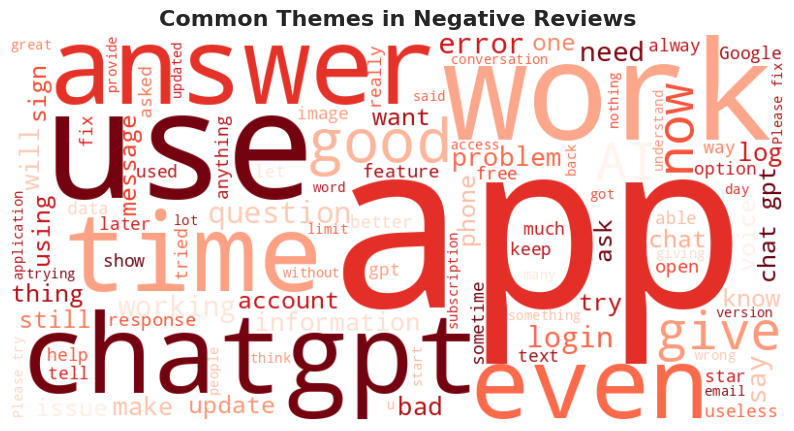

In [29]:
from textblob import TextBlob
from wordcloud import WordCloud
# Filter for only negative reviews
negative_reviews = df[df['Sentiment'] == 'Negative']['Review'].dropna()

# Combine all negative text into one string
neg_text = " ".join(review for review in negative_reviews)

# Generate a WordCloud to highlight common complaints
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=100).generate(neg_text)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Common Themes in Negative Reviews', fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

## 6. Time-Series Analysis
Track how user sentiment evolves over time (e.g., monthly/daily trends).


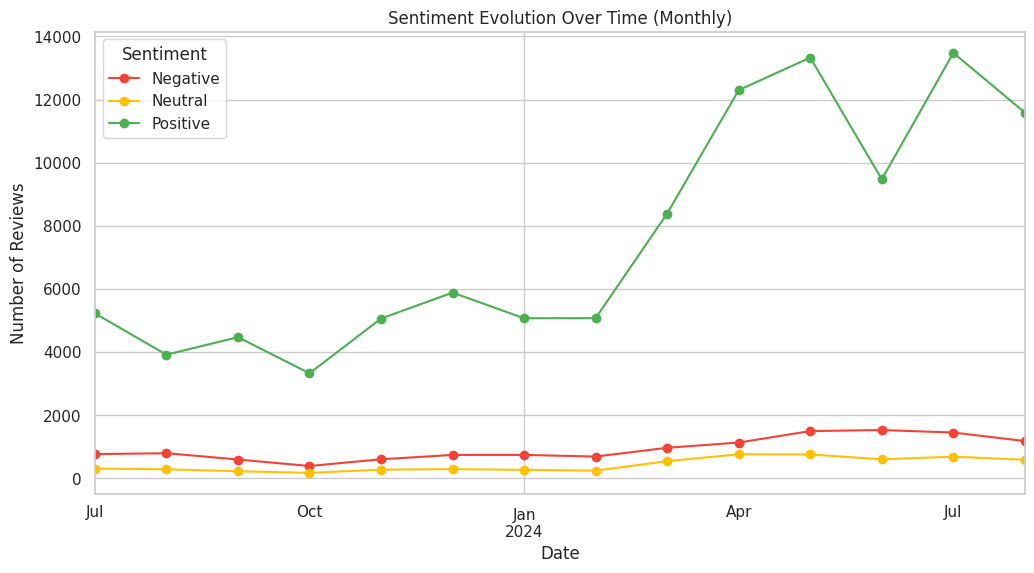

In [28]:
# Set date as index
df_time = df.set_index('Review Date')

# Resample by month and sentiment to get the count
monthly_sentiment = df_time.groupby([pd.Grouper(freq='M'), 'Sentiment']).size().unstack(fill_value=0)

# Plotting time-series trends
plt.figure(figsize=(12, 6))
monthly_sentiment.plot(kind='line', marker='o', ax=plt.gca(), color={'Positive':'#4CAF50', 'Negative':'#F44336', 'Neutral':'#FFC107'})
plt.title('Sentiment Evolution Over Time (Monthly)')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.grid(True)
plt.show()


### Insight

The monthly trend shows how the volume of positive, neutral, and negative reviews changes over time. Periods with noticeable increases in negative reviews may indicate periods worth investigating alongside product releases, service incidents, or other external events.

## 7. Conclusion and Recommendations
- **Overall Sentiment:** A majority of the users tend to have a specific sentiment (mostly positive based on rating distribution).
- **Core Issues:** The keyword/phrase extraction highlights specific areas of user friction (e.g., "network error", "login issue").
- **Trends:** Spikes in negative reviews over time could correlate with specific app updates or server outages.
  
**Actionable Items for the Product Team:**
1. Investigate and resolve the core technical issues highlighted in the negative review bigrams.
2. Monitor periods with spikes in negative sentiment to tie them back to specific releases or events.
3. Capitalize on the positive aspects frequently mentioned to guide future feature development.





# Advance Analysis

### What Drives Satisfaction vs. Frustration?

To understand not only what users dislike but also what they value, we compare the most common bigrams in positive and negative reviews.

This allows us to contrast recurring **drivers of satisfaction** with recurring **friction points**.

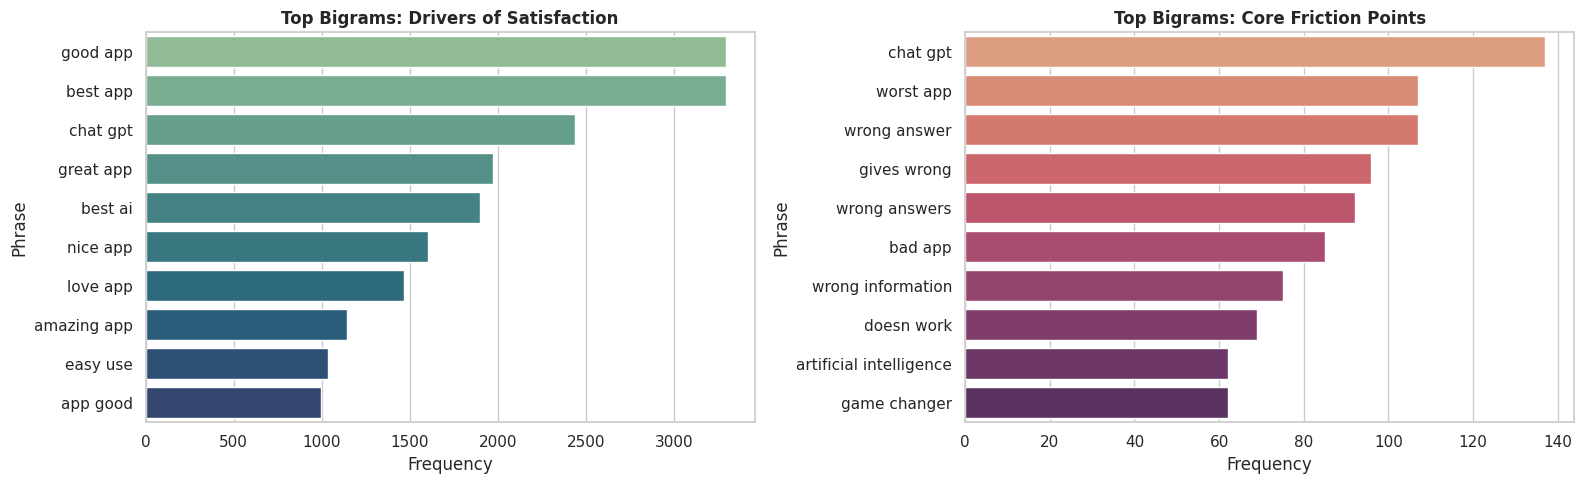

In [34]:
#  Deeper Context: Bigram Extraction (Two-word phrases)
def get_top_ngrams(corpus, ngram_range=(2,2), top_n=10):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return pd.DataFrame(words_freq[:top_n], columns=['Phrase', 'Frequency'])

positive_reviews = df[df['sentiment_class'] == 'Positive']['Review'].astype(str)
negative_reviews = df[df['sentiment_class'] == 'Negative']['Review'].astype(str)

top_pos_bigrams = get_top_ngrams(positive_reviews, (2, 2), 10)
top_neg_bigrams = get_top_ngrams(negative_reviews, (2, 2), 10)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x='Frequency', y='Phrase', data=top_pos_bigrams, ax=ax[0], palette='crest')
ax[0].set_title('Top Bigrams: Drivers of Satisfaction', fontweight='bold')

sns.barplot(x='Frequency', y='Phrase', data=top_neg_bigrams, ax=ax[1], palette='flare')
ax[1].set_title('Top Bigrams: Core Friction Points', fontweight='bold')

plt.tight_layout()
plt.show()


### Key Takeaway

The positive and negative phrase patterns reveal two sides of the user experience: themes associated with satisfaction can inform feature and experience improvements, while recurring negative phrases highlight areas where intervention may have the greatest impact.

### Polarity and Subjectivity

- **Polarity** measures whether the language is negative or positive.
- **Subjectivity** indicates whether the language is more factual or opinion-based.

This helps distinguish strongly positive/negative language from more neutral or objective reviews.

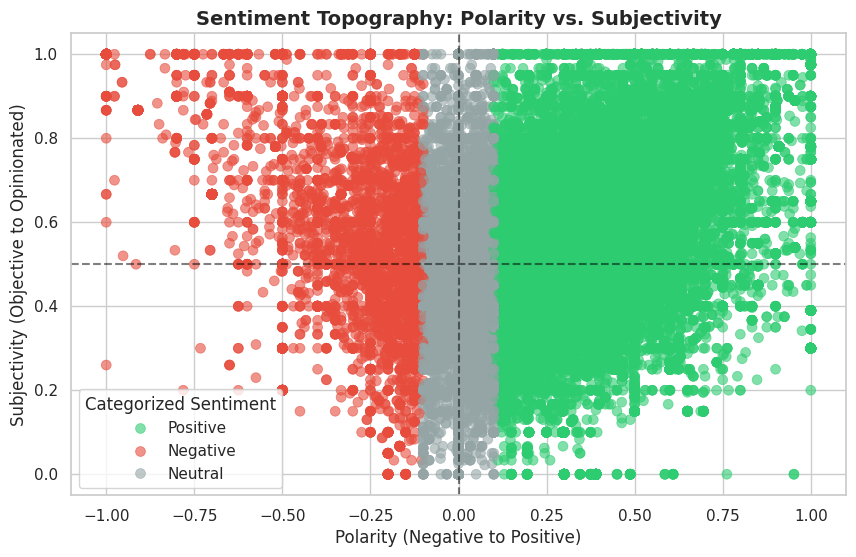

In [30]:
# Extract Sentiment Metrics
def extract_sentiment_metrics(text):
    blob = TextBlob(str(text))
    return pd.Series([blob.sentiment.polarity, blob.sentiment.subjectivity])

df[['polarity', 'subjectivity']] = df['Review'].apply(extract_sentiment_metrics)

# Categorize based on polarity threshold
df['sentiment_class'] = np.select(
    [df['polarity'] > 0.1, df['polarity'] < -0.1],
    ['Positive', 'Negative'],
    default='Neutral'
)

# Visualize Polarity vs Subjectivity
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='polarity', y='subjectivity', hue='sentiment_class',
                palette={'Positive': '#2ecc71', 'Neutral': '#95a5a6', 'Negative': '#e74c3c'},
                alpha=0.6, s=50, edgecolor=None)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.axhline(0.5, color='black', linestyle='--', alpha=0.5)
plt.title('Sentiment Topography: Polarity vs. Subjectivity', fontweight='bold', fontsize=14)
plt.xlabel('Polarity (Negative to Positive)')
plt.ylabel('Subjectivity (Objective to Opinionated)')
plt.legend(title='Categorized Sentiment')
plt.show()


### Insight

The distribution of reviews across polarity and subjectivity provides additional context beyond star ratings. Reviews with strong polarity indicate clearer emotional language, while reviews with higher subjectivity tend to contain more opinions or personal experiences.

In [37]:
# Text Cleaning setup for keyword extraction
custom_stopwords = {'the','a','an','is','it','in','on','at','to','of','and','or','but','for','with','this','that','are','was','were','be','been','being','have','has','had','do','does','did','will','would','could','should','may','might','can','i','my','me','we','our','you','your','they','them','their','its','so','very','just','not','no','than','more','from','by','as','if','into','about','up','out','get','got','one','all','also','some','any','even','too','only','much','many','s','t','app','chatgpt','chat','gpt'}

def clean_tokenize(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    words = [w for w in text.split() if w not in custom_stopwords and len(w) > 2]
    return words

df['tokens'] = df['Review'].apply(clean_tokenize)
pos_words = [w for tokens in df[df['sentiment_class'] == 'Positive']['tokens'] for w in tokens]
neg_words = [w for tokens in df[df['sentiment_class'] == 'Negative']['tokens'] for w in tokens]
neu_words = [w for tokens in df[df['sentiment_class'] == 'Neutral']['tokens'] for w in tokens]



### Sentiment-Specific Themes

These word clouds provide a qualitative comparison of the language used across positive, neutral, and negative reviews. They complement the more quantitative frequency analysis by showing how the vocabulary differs between sentiment groups.

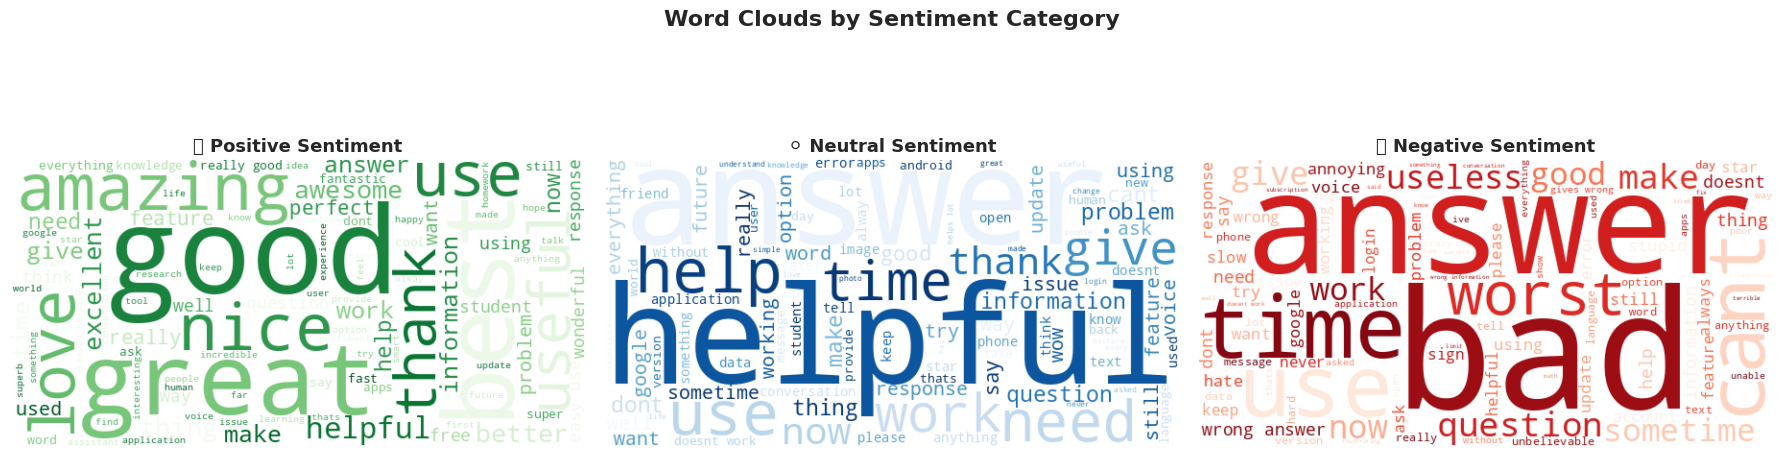

In [38]:
# Sentiment Wordclouds
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Word Clouds by Sentiment Category', fontsize=16, fontweight='bold', y=1.05)

def plot_wordcloud(word_list, colormap, ax, title):
    if not word_list:
        ax.set_title(title)
        ax.axis('off')
        return
    text = ' '.join(word_list)
    wc = WordCloud(width=600, height=300, background_color='white', colormap=colormap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.axis('off')


plot_wordcloud(pos_words, 'Greens', axes[0], '✅ Positive Sentiment')
plot_wordcloud(neu_words, 'Blues', axes[1], '⚪ Neutral Sentiment')
plot_wordcloud(neg_words, 'Reds', axes[2], '❌ Negative Sentiment')

plt.tight_layout()
plt.show()
